# Pipeline
This is where I build my pipeline.

## Idea
1. We will have two categories: Intersection and Address collisions (refer to `exploration.ipynb` for how I came to this conclusion).
2. We will separate the collisons dataset into two subsets, one for each category.

### Extract
1. Intersection and address collisions will have unrelated columns removed.
2. Intersection and address feature sets will also have unrelated columns removed, and will be transformed to contain only `id`, `description` and `geometry` columns.

### Transform
1. Intersection collisions will be mapped to the nearest intersection feature via spatial index, and string match score will be calculated via rapidfuzz
2. Address collisions will be mapped to the nearest address feature via spatial index, and string match score will be calculated via rapidfuzz

### Load
idk what happens now, I guess we just display the results.



# Code

## Initial setup

This is where we import necessary libraries and instantiate regex patterns and helper functions.

In [1]:
# Importing necessary libraries

import geopandas as gpd
import pandas as pd
from shapely.geometry import shape
from rapidfuzz import fuzz
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

extract_address_pattern = r'(\d{1,5}\w?\s{0,2}\w+\s?\w+)'

address_pattern = r'(?i)^(?!.*\b(?:hwy|ramp)\b)(\d{1,5}\w?(?:\s+\w+)+)'

offset_pattern = r'^\d.?\d*\s?[mM](etres)?\s?\w{1,5}'

# Function to fix multi point geoms
def to_point(geom):
    if geom.geom_type == "Point":
        return geom
    elif geom.geom_type == "MultiPoint":
        return list(geom.geoms)[0]  # take first point
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")

def plot_histogram(df, column, bins=50, percent_labels=False):
    sns.set_theme(style="whitegrid", context="talk")
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], bins=bins, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    if percent_labels:
        total = len(df[column])
        for p in plt.gca().patches:
            height = p.get_height()
            plt.gca().text(p.get_x() + p.get_width() / 2., height, f'{100 * height / total:.1f}%', ha="center")
    
    plt.show()

## Loading and processing collisions

In [2]:
# Loading the collision data
collision_data = pd.read_csv("../data/raw/collisions.csv")

# Extracting necessary columns
collision_data = collision_data[['collision_id', 'stname1', 'stname2', 'stname3', 'latitude', 'longitude']]

# Converting to GeoDataFrame
collision_data = gpd.GeoDataFrame(collision_data, geometry=gpd.points_from_xy(collision_data.longitude, collision_data.latitude), crs="EPSG:4326")

# Saving the processed collision data
collision_data.to_csv("../data/processed/collisions.csv", index=False)
collision_data.count()

collision_id    20455
stname1         20455
stname2         18697
stname3          4659
latitude        20452
longitude       20452
geometry        20455
dtype: int64

## Loading and processing intersections

In [3]:
# Initialize the intersection data
intersection_data = pd.read_csv('../data/raw/intersections.csv')

# Rename columns for consistency
intersection_data = intersection_data.rename(columns={'INTERSECTION_ID': 'feature_id', 'INTERSECTION_DESC': 'feature_description'})

# Adding type column for use with address data
intersection_data['type'] = 'intersection'

# Extract only necessary columns
intersection_data = intersection_data[['feature_id', 'feature_description', 'type', 'geometry']]

# Filter out rows where description is null or empty
intersection_data = intersection_data[intersection_data['feature_description'].notna() & (intersection_data['feature_description'].str.strip() != '')]

# Convert the geometry from WKT to shapely geometry
intersection_data["geometry"] = intersection_data["geometry"].apply(lambda x: shape(json.loads(x)))
intersection_data = gpd.GeoDataFrame(intersection_data, geometry='geometry', crs="EPSG:4326")

intersection_data['geometry'] = intersection_data['geometry'].apply(lambda x: to_point(x))

intersection_data.to_csv("../data/processed/intersections.csv", index=False)

intersection_data.count()

feature_id             46257
feature_description    46257
type                   46257
geometry               46257
dtype: int64

## Loading and processing address boundaries

In [4]:
address_boundaries = pd.read_csv("../data/raw/property-boundaries.csv")

# Clean the address boundaries data by removing rows with missing or invalid addresses
address_boundaries = address_boundaries[address_boundaries['ADDRESS_NUMBER'].notnull() & address_boundaries['LINEAR_NAME_FULL'].notnull()]

# Renaming columns for consistency and simplicity
address_boundaries = address_boundaries.rename(columns={'PARCELID': 'feature_id', 'ADDRESS_NUMBER': 'address_number', 'LINEAR_NAME_FULL': 'street_name'})

address_boundaries = address_boundaries[['feature_id', 'address_number', 'street_name', 'geometry']]

# Combining address number and street name for easier matching with collision data
address_boundaries['feature_description'] = address_boundaries['address_number'].astype(str) + ' ' + address_boundaries['street_name']
address_boundaries = address_boundaries.drop(columns=['address_number', 'street_name'])

# Adding type column for use with intersection data
address_boundaries['type'] = 'address_boundary'

# Convert the geometry from WKT to shapely geometry
address_boundaries["geometry"] = address_boundaries["geometry"].apply(lambda x: shape(json.loads(x)))
address_boundaries = gpd.GeoDataFrame(address_boundaries, geometry='geometry', crs="EPSG:4326")

# Saving the cleaned address boundaries data
address_boundaries.to_csv("../data/processed/address_boundaries.csv", index=False)

address_boundaries.head()

,feature_id,geometry,feature_description,type
0,5090819,"MULTIPOLYGON (((-79.5231 43.77439, -79.52194 4...",5000 Jane St,address_boundary
1,5093788,"MULTIPOLYGON (((-79.52592 43.77311, -79.52574 ...",343 Hullmar Dr,address_boundary
4,5124997,"MULTIPOLYGON (((-79.558 43.75894, -79.55944 43...",40 Millwick Dr,address_boundary
5,5094544,"MULTIPOLYGON (((-79.52561 43.77249, -79.52574 ...",24 Wheelwright Cres,address_boundary
6,5095105,"MULTIPOLYGON (((-79.52664 43.77261, -79.52651 ...",36 Wheelwright Cres,address_boundary


## Separating address collisions from the rest of the collisions

In [5]:
address_collisions = collision_data[collision_data['stname1'].str.match(address_pattern, na=False) | collision_data['stname2'].str.match(address_pattern, na=False)]

address_collisions.count()

collision_id    1948
stname1         1948
stname2          201
stname3          596
latitude        1948
longitude       1948
geometry        1948
dtype: int64

## Separating intersection collisions from the rest of the collisions

In [6]:
intersection_collisions = collision_data[~collision_data['collision_id'].isin(address_collisions['collision_id'])]

intersection_collisions.count()

collision_id    18507
stname1         18507
stname2         18496
stname3          4063
latitude        18504
longitude       18504
geometry        18507
dtype: int64

# Reproject geodataframes to common CRS

In [7]:
intersection_data = intersection_data.to_crs(epsg=32617)

intersection_collisions = intersection_collisions.to_crs(epsg=32617)

address_collisions = address_collisions.to_crs(epsg=32617)

address_boundaries = address_boundaries.to_crs(epsg=32617)

## Spatially joining collisions and features

### Intersections

In [8]:
intersection_collisions.dropna(subset=['latitude', 'longitude'], inplace=True)

print(intersection_collisions.count())

print(intersection_collisions.is_valid.all())
print(intersection_data.is_valid.all())

collision_id    18504
stname1         18504
stname2         18493
stname3          4063
latitude        18504
longitude       18504
geometry        18504
dtype: int64
True
True


In [9]:
intersection_merged = gpd.sjoin_nearest(intersection_collisions, intersection_data, distance_col="distance", how="left")

print(intersection_merged.count())

intersection_merged['stname2'] = intersection_merged['stname2'].fillna("")

intersection_merged['collision_description'] = (intersection_merged['stname1'] + " " + intersection_merged['stname2']).str.lower()

intersection_merged['feature_description'] = intersection_merged['feature_description'].str.lower().str.replace("/", "")
intersection_merged.head()

collision_id           19236
stname1                19236
stname2                19225
stname3                 4290
latitude               19236
longitude              19236
geometry               19236
index_right            19236
feature_id             19236
feature_description    19236
type                   19236
distance               19236
dtype: int64


,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description
0,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (635468.037 4839881.61),11335,13458111,woodbine ave ventnor ave,intersection,37.820986,woodbine ave o connor dr
1,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (635468.037 4839881.61),11335,13458111,woodbine ave ventnor ave,intersection,37.820986,woodbine ave o connor dr
2,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (635468.037 4839881.61),11335,13458111,woodbine ave ventnor ave,intersection,37.820986,woodbine ave o connor dr
3,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (635468.037 4839881.61),11335,13458111,woodbine ave ventnor ave,intersection,37.820986,woodbine ave o connor dr
4,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (635468.037 4839881.61),11335,13458111,woodbine ave ventnor ave,intersection,37.820986,woodbine ave o connor dr


### Addresses

In [10]:
address_collisions.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry
53,2006:886552,3367 DUNDAS ST W,NaN,NaN,43.665544,-79.482891,POINT (622314.732 4835844.893)
54,2006:886552,3367 DUNDAS ST W,NaN,NaN,43.665544,-79.482891,POINT (622314.732 4835844.893)
65,2006:884310,460 CORONATION DR,NaN,NaN,43.765044,-79.170390,POINT (647266.074 4847404.011)
66,2006:884310,460 CORONATION DR,NaN,NaN,43.765044,-79.170390,POINT (647266.074 4847404.011)
67,2006:884310,460 CORONATION DR,NaN,NaN,43.765044,-79.170390,POINT (647266.074 4847404.011)


In [11]:
address_merged = gpd.sjoin_nearest(address_collisions, address_boundaries, how="left", distance_col="distance")

# Filling null values with empty string to help with concat
address_merged['stname2'] = address_merged['stname2'].fillna("")

# Combining stname1 and stname2 to create a full description for matching
address_merged['collision_description'] = (address_merged['stname1'] + " " + address_merged["stname2"]).str.lower()

# Extracting the relevant part of the collision description using the address pattern
address_merged['collision_description'] = address_merged['collision_description'].str.extract(extract_address_pattern, expand=False)

# Cleaning up the feature description by converting to lowercase
address_merged['feature_description'] = address_merged['feature_description'].str.lower()
address_merged.count()

collision_id             1948
stname1                  1948
stname2                  1948
stname3                   596
latitude                 1948
longitude                1948
geometry                 1948
index_right              1948
feature_id               1948
feature_description      1948
type                     1948
distance                 1948
collision_description    1948
dtype: int64

## Determine correct feature

### Intersections

In [12]:
# Compute string similarity scores

intersection_merged['match_score'] = [fuzz.token_sort_ratio(loc, desc) for loc, desc in zip(intersection_merged['collision_description'], intersection_merged['feature_description'])]

# Pick the feature with the highest string similarity score for each collision
intersection_merged_sorted = intersection_merged.sort_values(by=['match_score'], ascending=False)

intersection_merged = intersection_merged_sorted.loc[~intersection_merged_sorted.index.duplicated(keep="first")]

intersection_merged.count()


collision_id             18504
stname1                  18504
stname2                  18504
stname3                   4063
latitude                 18504
longitude                18504
geometry                 18504
index_right              18504
feature_id               18504
feature_description      18504
type                     18504
distance                 18504
collision_description    18504
match_score              18504
dtype: int64

### Addresses

In [13]:
# Compute string similarity scores
address_merged['match_score'] = [fuzz.token_sort_ratio(loc, desc) for loc, desc in zip(address_merged['collision_description'], address_merged['feature_description'])]

address_merged_sorted = address_merged.sort_values(by=['match_score'], ascending=False)

# Pick the feature with the highest string similarity score for each collision
address_merged = address_merged_sorted.loc[~address_merged_sorted.index.duplicated(keep="first")]

address_merged.count()

collision_id             1948
stname1                  1948
stname2                  1948
stname3                   596
latitude                 1948
longitude                1948
geometry                 1948
index_right              1948
feature_id               1948
feature_description      1948
type                     1948
distance                 1948
collision_description    1948
match_score              1948
dtype: int64

## Interpret Results

This is where we analyze the `distance` and `match_score` columns to interpret any patterns

### Intersections

In [14]:
intersection_merged.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score
20454,2025:5001386641,MILL ST,Rolling Mills Rd,6 m South of,43.651755,-79.354764,POINT (632675.305 4834510.303),37805,30043794,rolling mills rd mill st,intersection,41.286418,mill st rolling mills rd,100.0
20453,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0
20426,2025:5001386641,MILL ST,Rolling Mills Rd,6 m South of,43.651755,-79.354764,POINT (632675.305 4834510.303),37805,30043794,rolling mills rd mill st,intersection,41.286418,mill st rolling mills rd,100.0
20424,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0
20423,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0


In [15]:
intersection_merged[['distance', 'match_score']].describe()

,distance,match_score
count,18504.000000,18504.000000
mean,20.706351,86.719574
std,31.739362,19.177820
min,0.069788,10.526316
25%,3.312095,75.000000
50%,7.940189,100.000000
75%,21.044372,100.000000
max,411.611570,100.000000


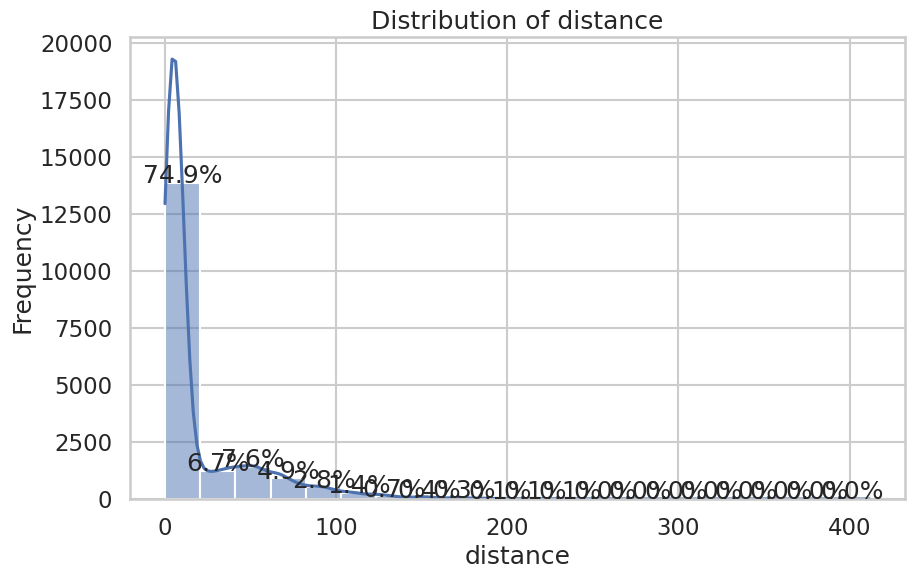

In [16]:
plot_histogram(intersection_merged, 'distance', bins=20, percent_labels=True)

Approximately 75% of intersection collisions have a `distance` within 20m.

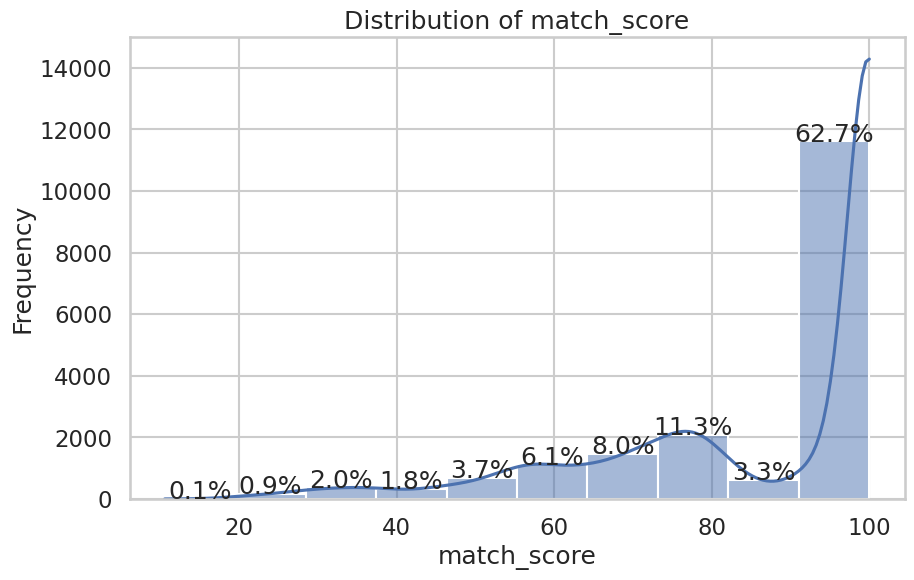

In [17]:
plot_histogram(intersection_merged, 'match_score', bins=10, percent_labels=True)

In [18]:
targets = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 0]

# Grab the first occurrence of each target score
examples = pd.concat([intersection_merged[intersection_merged['match_score'] == t].head(1) for t in targets])

display(examples)

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score
20454,2025:5001386641,MILL ST,Rolling Mills Rd,6 m South of,43.651755,-79.354764,POINT (632675.305 4834510.303),37805,30043794,rolling mills rd mill st,intersection,41.286418,mill st rolling mills rd,100.0
4090,2008:1074830,ROGERS Road,SCOTT Road,NaN,43.682344,-79.469091,POINT (623392.919 4837731.193),6402,13461548,rogers rd scott rd,intersection,4.976591,rogers road scott road,90.0
18650,2023:3001801230,WESTON RD,BLACK CREEK DR,3 m West of,43.683367,-79.480283,POINT (622488.768 4837828.212),10413,13461391,weston rd black creek dr humber blvd,intersection,9.525476,weston rd black creek dr,80.0
16004,2019:9001878764,KIPLING AVE,BETHRIDGE RD,NaN,43.707353,-79.564701,POINT (615638.485 4840370.988),45292,13457273,kipling ave hepc,intersection,39.333230,kipling ave bethridge rd,70.0
7150,2011:1244229,QUEEN Stre W,DUFFERIN,NaN,43.642044,-79.429191,POINT (626693.681 4833315.477),5825,13468005,queen st w noble st,intersection,41.376985,queen stre w dufferin,60.0
3042,2008:1025489,BROADVIEW AVE,ALLEN AVE,NaN,43.663644,-79.351891,POINT (632880.767 4835835.332),41649,13464398,broadview ave mountstephen st,intersection,46.030770,broadview ave allen ave,50.0
800,2006:917225,MOUNT PLEASANT RD,SOUTH DR,NaN,43.677644,-79.380591,POINT (630536.408 4837344.657),43126,30154207,scarth rd,intersection,24.304985,mount pleasant rd south dr,40.0


### Addresses

In [19]:
address_merged[['distance', 'match_score']].describe()

,distance,match_score
count,1948.000000,1948.000000
mean,11.814998,78.485562
std,12.461830,22.682777
min,0.000000,18.750000
25%,7.563920,75.000000
50%,10.134557,86.666667
75%,13.721229,93.333333
max,166.839294,100.000000


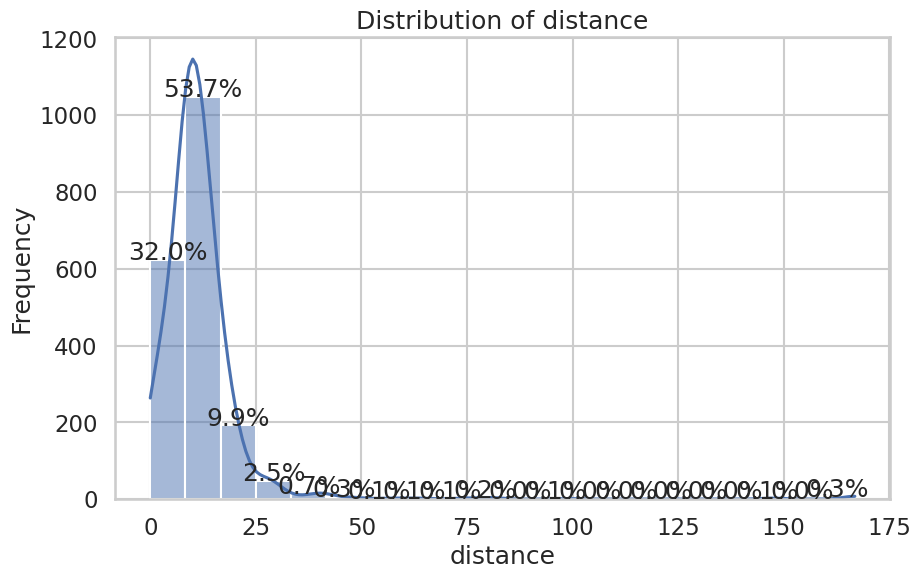

In [20]:
plot_histogram(address_merged, 'distance', bins=20, percent_labels=True)

Approximately 95.6% of distances appear to be within 25m.

In [21]:
targets = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10, 0]

# Grab the first occurrence of each target score
examples = pd.concat([address_merged[address_merged['match_score'] == t].head(1) for t in targets])

display(examples)

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score
20378,2026:6000455396,Sewells RD,1216 Sewells RD,NaN,43.842260,-79.207409,POINT (644100.567 4855914.942),514834,5000058,1216 sewells rd,address_boundary,9.454451,1216 sewells rd,100.0
20436,2024:4002513456,2255 VICTORIA PARK AVE,YORK MILLS RD,60 m South of,43.762464,-79.317239,POINT (635451.821 4846866.765),310690,5117234,2255 victoria park ave,address_boundary,13.320298,2255 victoria park,90.0
12477,2016:6000576751,200 NORSEMAN ST,,420 m West of,43.632871,-79.524762,POINT (619003.402 4832155.269),445157,5498974,197 norseman st,address_boundary,8.292435,200 norseman st,80.0
12606,2016:6000936557,4 EWART AVE,,NaN,43.688112,-79.467434,POINT (623514.64 4838374.273),510326,5322562,464 silverthorn ave,address_boundary,11.216498,4 ewart ave,60.0
1193,2006:932486,2650 FINCH AVE W,,NaN,43.746644,-79.566691,POINT (615402.687 4844732.03),494077,5158748,2773 islington ave,address_boundary,21.037199,2650 finch ave,50.0
19593,2024:4002255012,65 SKYMARK DR,FINCH AVE E,5 m North of,43.794901,-79.353345,POINT (632473.857 4850411.012),351462,5047331,3555 don mills rd,address_boundary,9.920132,65 skymark dr,40.0


## Handle Offset Collisions

Both intersection and address collision subsets contain a number of collisions with "offsets" in `stname3`. We will separate these collisions from the rest, extract the number of metres described in the offset, and then subtract this number from the calculated distance.


In [22]:
intersection_offset_collisions = intersection_merged[intersection_merged['stname3'].str.match(offset_pattern, na=False)]

address_offset_collisions = address_merged[address_merged['stname3'].str.match(offset_pattern, na=False)]

print(intersection_offset_collisions["collision_id"].count())

print(address_offset_collisions["collision_id"].count())

3969
578


In [23]:
intersection_offset_collisions.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score
20454,2025:5001386641,MILL ST,Rolling Mills Rd,6 m South of,43.651755,-79.354764,POINT (632675.305 4834510.303),37805,30043794,rolling mills rd mill st,intersection,41.286418,mill st rolling mills rd,100.0
20453,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0
20426,2025:5001386641,MILL ST,Rolling Mills Rd,6 m South of,43.651755,-79.354764,POINT (632675.305 4834510.303),37805,30043794,rolling mills rd mill st,intersection,41.286418,mill st rolling mills rd,100.0
20424,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0
20423,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920,13470434,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0


In [24]:
address_offset_collisions.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score
13711,2017:7001100297,5799 YONGE ST,,2 m East of,43.784887,-79.416783,POINT (627391.46 4849199.227),513384,10645732,5799 yonge st,address_boundary,15.312061,5799 yonge st,100.0
13710,2017:7001100297,5799 YONGE ST,,2 m East of,43.784887,-79.416783,POINT (627391.46 4849199.227),513384,10645732,5799 yonge st,address_boundary,15.312061,5799 yonge st,100.0
13618,2017:7000940892,66 BLACKSMITH CRES,,2 m West of,43.771647,-79.524564,POINT (618745.138 4847568.483),17,5097340,66 blacksmith cres,address_boundary,0.000000,66 blacksmith cres,100.0
13483,2017:7000665292,61 TOPCLIFF AVE,,47 m East of,43.756456,-79.508297,POINT (620084.702 4845904.792),491042,5134024,61 topcliff ave,address_boundary,4.553319,61 topcliff ave,100.0
13482,2017:7000665292,61 TOPCLIFF AVE,,47 m East of,43.756456,-79.508297,POINT (620084.702 4845904.792),491042,5134024,61 topcliff ave,address_boundary,4.553319,61 topcliff ave,100.0


In [25]:
intersection_offset_collisions["offset"] = intersection_offset_collisions['stname3'].str.extract(r"(\d+)")
intersection_offset_collisions["offset"] = pd.to_numeric(intersection_offset_collisions["offset"], errors="coerce")
intersection_offset_collisions.head()
intersection_offset_collisions["offset"].isna().count() // intersection_offset_collisions["offset"].count()

np.int64(1)

In [26]:
address_offset_collisions["offset"] = address_offset_collisions['stname3'].str.extract(r"(\d+)")
address_offset_collisions["offset"] = pd.to_numeric(address_offset_collisions["offset"], errors="coerce")
address_offset_collisions.head()
address_offset_collisions['offset'].isna().count() // address_offset_collisions['offset'].count()

np.int64(1)

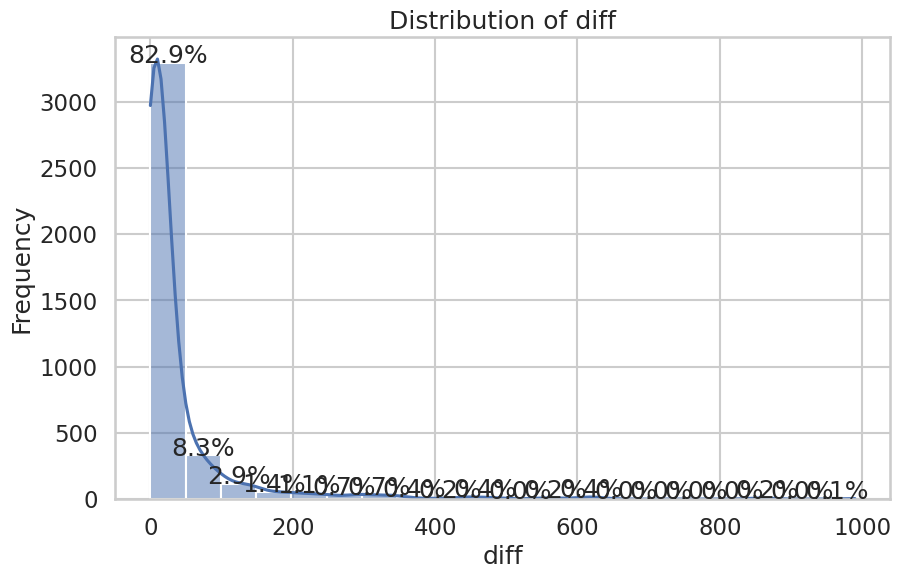

count    3969.000000
mean       38.062845
std        88.677197
min         0.007752
25%         3.755972
50%        10.019328
75%        28.077790
max       989.749947
Name: diff, dtype: float64

In [27]:
intersection_offset_collisions["diff"] = abs(intersection_offset_collisions["distance"] - intersection_offset_collisions["offset"])
intersection_offset_collisions.head()

plot_histogram(intersection_offset_collisions, "diff", bins=20, percent_labels=True)

intersection_offset_collisions['diff'].describe()

In [32]:
intersection_offset_collisions[intersection_offset_collisions['diff'] > 100]

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score,offset,diff
18494,2023:3001301183,SAWMILL RD,DOLORES RD,150 m South of,43.747130,-79.508725,POINT (620068.892 4844868.335),13082,13451032,sawmill rd dolores rd,intersection,2.619275,sawmill rd dolores rd,100.000000,150,147.380725
18493,2023:3001301183,SAWMILL RD,DOLORES RD,150 m South of,43.747130,-79.508725,POINT (620068.892 4844868.335),13082,13451032,sawmill rd dolores rd,intersection,2.619275,sawmill rd dolores rd,100.000000,150,147.380725
15833,2019:9001468146,BATHURST ST,HERRICK ST,233 m South of,43.662955,-79.410367,POINT (628167.479 4835666.76),38054,13464760,bathurst st herrick st,intersection,33.543843,bathurst st herrick st,100.000000,233,199.456157
15832,2019:9001468146,BATHURST ST,HERRICK ST,233 m South of,43.662955,-79.410367,POINT (628167.479 4835666.76),38054,13464760,bathurst st herrick st,intersection,33.543843,bathurst st herrick st,100.000000,233,199.456157
15831,2019:9001468146,BATHURST ST,HERRICK ST,233 m South of,43.662955,-79.410367,POINT (628167.479 4835666.76),38054,13464760,bathurst st herrick st,intersection,33.543843,bathurst st herrick st,100.000000,233,199.456157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19308,2024:4001138824,GARDINER XWY W,YORK ST,364 m West of,43.638811,-79.391232,POINT (629762.242 4833015.075),39971,30127955,waterfront trl,intersection,14.446790,gardiner xwy w york st,22.222222,364,349.553210
19311,2024:4001138824,GARDINER XWY W,YORK ST,364 m West of,43.638811,-79.391232,POINT (629762.242 4833015.075),39971,30127955,waterfront trl,intersection,14.446790,gardiner xwy w york st,22.222222,364,349.553210
19307,2024:4001138824,GARDINER XWY W,YORK ST,364 m West of,43.638811,-79.391232,POINT (629762.242 4833015.075),39971,30127955,waterfront trl,intersection,14.446790,gardiner xwy w york st,22.222222,364,349.553210
12965,2016:6001622859,SHEPPARD AVE E,VANDORF ST,1 m East of,43.802381,-79.154285,POINT (648469.93 4851579.655),31045,13443096,shallice crt,intersection,120.846424,sheppard ave e vandorf st,21.621622,1,119.846424


In [29]:
print(intersection_offset_collisions['offset'].describe())

intersection_offset_collisions[intersection_offset_collisions['offset'] == 1000]

count    3969.000000
mean       61.598136
std       103.901837
min         1.000000
25%         7.000000
50%        24.000000
75%        70.000000
max      1000.000000
Name: offset, dtype: float64


,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score,offset,diff
19581,2024:4002233011,DON VALLEY PY N,YORK MILLS RD,1000 m South of,43.74947,-79.333412,POINT (634179.007 4845397.238),22476,13450290,dvp don river e branch,intersection,10.250053,don valley py n york mills rd,39.215686,1000,989.749947
19583,2024:4002233011,DON VALLEY PY N,YORK MILLS RD,1000 m South of,43.74947,-79.333412,POINT (634179.007 4845397.238),22476,13450290,dvp don river e branch,intersection,10.250053,don valley py n york mills rd,39.215686,1000,989.749947
19582,2024:4002233011,DON VALLEY PY N,YORK MILLS RD,1000 m South of,43.74947,-79.333412,POINT (634179.007 4845397.238),22476,13450290,dvp don river e branch,intersection,10.250053,don valley py n york mills rd,39.215686,1000,989.749947


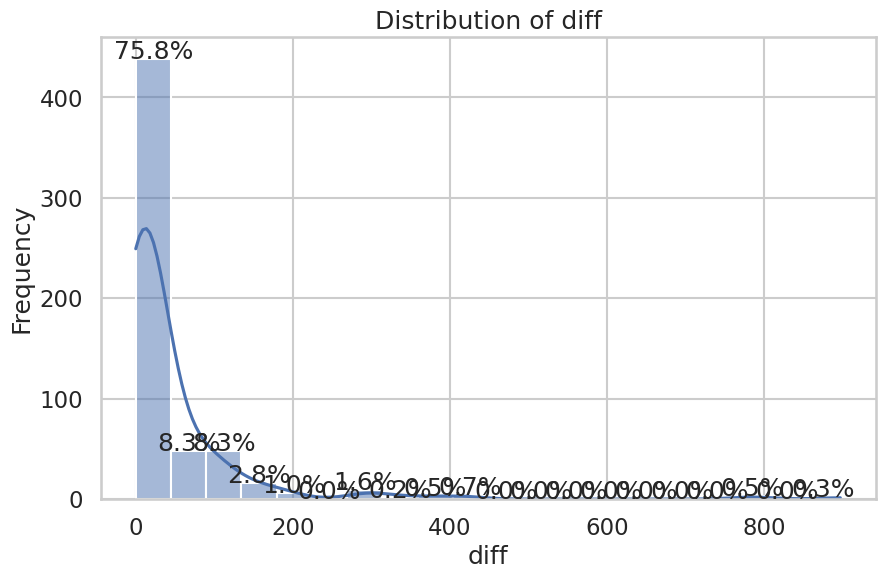

In [30]:
address_offset_collisions["diff"] = abs(address_offset_collisions["distance"] - address_offset_collisions["offset"])
address_offset_collisions.head()

plot_histogram(address_offset_collisions, "diff", bins=20, percent_labels=True)

In [31]:
address_offset_collisions[address_offset_collisions['distance'] >= 80]

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score,offset,diff
